In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

# Dataset paths
occupancy = pd.read_csv("dataset/lot_occupancy_hourly.csv")
parking = pd.read_csv("dataset/parking_lots.csv")
reviews = pd.read_csv("dataset/reviews.csv")

print("Occupancy:", occupancy.shape)
print("Parking lots:", parking.shape)
print("Reviews:", reviews.shape)


Occupancy: (4575, 11)
Parking lots: (40, 13)
Reviews: (1500, 8)


In [5]:
# Create average rating for each parking lot
rating_df = (
    reviews.groupby("lot_id", as_index=False)
    .agg(
        avg_rating=("rating", "mean"),
        review_count=("rating", "count")
    )
)

# Merge occupancy + parking details + ratings
df = (
    occupancy
    .merge(
        parking[
            [
                "parking_lots_id", "name", "address", "latitude", "longitude",
                "price_per_hour", "total_slots", "vehicle_type", "status"
            ]
        ],
        left_on="lot_id",
        right_on="parking_lots_id",
        how="left"
    )
    .merge(rating_df, on="lot_id", how="left")
)

# Fill missing ratings with the overall review mean
df["avg_rating"] = df["avg_rating"].fillna(reviews["rating"].mean())
df["price"] = df["price_per_hour"]

print("Merged shape:", df.shape)
df.head()


Merged shape: (4575, 23)


,lot_id,date,hour,day_of_week,is_weekend,is_festival,weather_condition,avg_price,bookings_count,total_slots_x,occupancy_pct,parking_lots_id,name,address,latitude,longitude,price_per_hour,total_slots_y,vehicle_type,status,avg_rating,review_count,price
0,P115,2025-10-01,12,Wednesday,False,False,clear,19.40,1,77,1.3,P115,Pitampura Parking E,"Pitampura, Delhi",28.700686,77.134562,28.57,25,all,approved,3.863636,44,28.57
1,P115,2025-10-01,15,Wednesday,False,False,rain,22.98,1,77,1.3,P115,Pitampura Parking E,"Pitampura, Delhi",28.700686,77.134562,28.57,25,all,approved,3.863636,44,28.57
2,P115,2025-10-02,7,Thursday,False,False,cloudy,20.62,1,77,1.3,P115,Pitampura Parking E,"Pitampura, Delhi",28.700686,77.134562,28.57,25,all,approved,3.863636,44,28.57
3,P115,2025-10-02,19,Thursday,False,False,cloudy,23.32,1,77,1.3,P115,Pitampura Parking E,"Pitampura, Delhi",28.700686,77.134562,28.57,25,all,approved,3.863636,44,28.57
4,P115,2025-10-03,11,Friday,False,False,rain,23.09,1,77,1.3,P115,Pitampura Parking E,"Pitampura, Delhi",28.700686,77.134562,28.57,25,all,approved,3.863636,44,28.57


In [6]:
# User location used for distance calculation.
# Replace these values with the actual user/destination coordinates.
USER_LAT = 25.6242129
USER_LON = 85.0850287

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(
    USER_LAT,
    USER_LON,
    df["latitude"].values,
    df["longitude"].values
)

df[[
    "name", "address", "price",
    "avg_rating", "distance_km", "occupancy_pct"
]].head()


,name,address,price,avg_rating,distance_km,occupancy_pct
0,Pitampura Parking E,"Pitampura, Delhi",28.57,3.863636,857.449203,1.3
1,Pitampura Parking E,"Pitampura, Delhi",28.57,3.863636,857.449203,1.3
2,Pitampura Parking E,"Pitampura, Delhi",28.57,3.863636,857.449203,1.3
3,Pitampura Parking E,"Pitampura, Delhi",28.57,3.863636,857.449203,1.3
4,Pitampura Parking E,"Pitampura, Delhi",28.57,3.863636,857.449203,1.3


In [7]:
## Train the Occupancy Prediction Model
'''
Target: `occupancy_pct`

**Features:**
- `price`
- `avg_rating`
- `distance_km`
'''


features = ["price", "avg_rating", "distance_km"]
target = "occupancy_pct"

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

# Same accuracy-style metric used in the original notebook
accuracy = 100 - (
    mae / np.mean(np.abs(y_test)) * 100
)

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R²       : {r2:.3f}")
print(f"Accuracy : {accuracy:.2f}%")


MAE      : 0.23
RMSE     : 0.69
R²       : 0.823
Accuracy : 91.87%


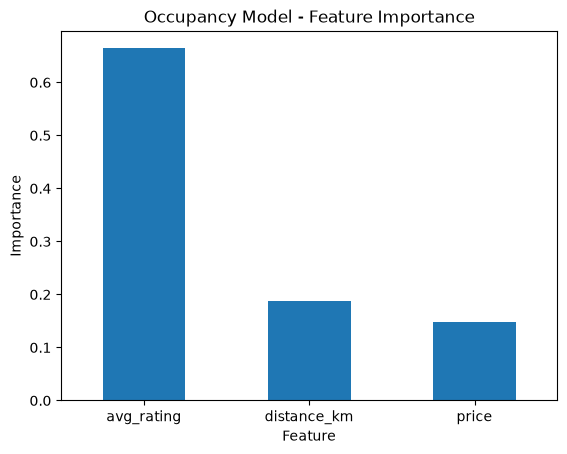

In [8]:
# Feature importance
importance = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

importance.plot(kind="bar")
plt.title("Occupancy Model - Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=0)
plt.show()


In [10]:
# Save the trained occupancy model and the information needed by
# the recommendation notebook.
model_bundle = {
    "model": model,
    "features": features,
    "user_lat": USER_LAT,
    "user_lon": USER_LON
}

joblib.dump(model_bundle, "occupancy_model.joblib")

print("Saved: occupancy_model.joblib")


Saved: occupancy_model.joblib


In [11]:
# Load the saved occupancy model
bundle = joblib.load("occupancy_model.joblib")

loaded_model = bundle["model"]
features = bundle["features"]

# Generate occupancy predictions
df["predicted_occupancy"] = loaded_model.predict(df[features])

# Keep predictions between 0 and 100
df["predicted_occupancy"] = df["predicted_occupancy"].clip(0, 100)

# Display predictions
print(df[features + ["predicted_occupancy"]].head(10))

   price  avg_rating  distance_km  predicted_occupancy
0  28.57    3.863636   857.449203             1.376127
1  28.57    3.863636   857.449203             1.376127
2  28.57    3.863636   857.449203             1.376127
3  28.57    3.863636   857.449203             1.376127
4  28.57    3.863636   857.449203             1.376127
5  28.57    3.863636   857.449203             1.376127
6  28.57    3.863636   857.449203             1.376127
7  28.57    3.863636   857.449203             1.376127
8  28.57    3.863636   857.449203             1.376127
9  28.57    3.863636   857.449203             1.376127


In [12]:
print(df.columns.tolist())

['lot_id', 'date', 'hour', 'day_of_week', 'is_weekend', 'is_festival', 'weather_condition', 'avg_price', 'bookings_count', 'total_slots_x', 'occupancy_pct', 'parking_lots_id', 'name', 'address', 'latitude', 'longitude', 'price_per_hour', 'total_slots_y', 'vehicle_type', 'status', 'avg_rating', 'review_count', 'price', 'distance_km', 'predicted_occupancy']


In [13]:
# Create data for the ML-based heatmap

heatmap_df = df[
    [
        "lot_id",
        "name",
        "latitude",
        "longitude",
        "predicted_occupancy"
    ]
].dropna()

# Keep predictions within 0–100%
heatmap_df["predicted_occupancy"] = heatmap_df[
    "predicted_occupancy"
].clip(0, 100)

print(heatmap_df.head(10))

  lot_id                 name   latitude  longitude  predicted_occupancy
0   P115  Pitampura Parking E  28.700686  77.134562             1.376127
1   P115  Pitampura Parking E  28.700686  77.134562             1.376127
2   P115  Pitampura Parking E  28.700686  77.134562             1.376127
3   P115  Pitampura Parking E  28.700686  77.134562             1.376127
4   P115  Pitampura Parking E  28.700686  77.134562             1.376127
5   P115  Pitampura Parking E  28.700686  77.134562             1.376127
6   P115  Pitampura Parking E  28.700686  77.134562             1.376127
7   P115  Pitampura Parking E  28.700686  77.134562             1.376127
8   P115  Pitampura Parking E  28.700686  77.134562             1.376127
9   P115  Pitampura Parking E  28.700686  77.134562             1.376127


In [15]:
print("Total rows:", len(df))
print("Unique parking lots:", df["lot_id"].nunique())


Total rows: 4575
Unique parking lots: 32


In [16]:
print(
    df.groupby("lot_id").size().sort_values(ascending=False).head(10)
)

lot_id
P125    163
P110    161
P121    157
P107    157
P128    156
P120    154
P109    153
P103    153
P132    153
P119    153
dtype: int64


In [18]:
# Create one heatmap point per parking lot

heatmap_df = (
    df.groupby("lot_id")
      .agg({
          "name": "first",
          "latitude": "first",
          "longitude": "first",
          "predicted_occupancy": "mean"
      })
      .reset_index()
)

# Keep predictions within 0–100%
heatmap_df["predicted_occupancy"] = (
    heatmap_df["predicted_occupancy"].clip(0, 100)
)

print("Number of parking lots:", len(heatmap_df))
print(heatmap_df.head(10))

Number of parking lots: 32
  lot_id                       name   latitude  longitude  predicted_occupancy
0   P101           Rohini Parking A  28.746245  77.058964             1.582225
1   P102            Saket Parking B  28.521139  77.203302             2.034599
2   P103     Lajpat Nagar Parking C  28.569873  77.240638             1.829639
3   P104      Nehru Place Parking D  28.549175  77.254786             1.561049
4   P105        Pitampura Parking E  28.699170  77.133056             2.158449
5   P106        Janakpuri Parking A  28.620621  77.085919             1.856073
6   P107  Greater Kailash Parking B  28.553980  77.240237             2.122604
7   P108     Lajpat Nagar Parking C  28.566360  77.243951             2.847814
8   P109        Pitampura Parking D  28.702073  77.130505             6.230335
9   P110        Pitampura Parking E  28.698135  77.126797             2.317855


In [22]:
import json

heatmap_data = heatmap_df.to_dict(orient="records")

with open("heatmap_predictions.json", "w") as f:
    json.dump(heatmap_data, f, indent=4)

print("Saved: heatmap_predictions.json")

Saved: heatmap_predictions.json


In [24]:
import json

with open("heatmap_predictions.json", "r") as f:
    data = json.load(f)

print("Total heatmap locations:", len(data))
print(data[:3])

Total heatmap locations: 32
[{'lot_id': 'P101', 'name': 'Rohini Parking A', 'latitude': 28.746245, 'longitude': 77.058964, 'predicted_occupancy': 1.582225393099512}, {'lot_id': 'P102', 'name': 'Saket Parking B', 'latitude': 28.521139, 'longitude': 77.203302, 'predicted_occupancy': 2.0345987666835073}, {'lot_id': 'P103', 'name': 'Lajpat Nagar Parking C', 'latitude': 28.569873, 'longitude': 77.240638, 'predicted_occupancy': 1.8296389289132975}]


In [46]:
# 1. Select features
features = [
    "price",
    "avg_rating",
    "distance_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_festival",
    "weather_condition"
]
target = "occupancy_pct"


In [54]:
model_df = df[features + [target]].copy()
model_df = model_df.dropna()
print("Rows used:", len(model_df))

Rows used: 4575


In [55]:
X = model_df[features]
y = model_df[target]
categorical_features = [
    "weather_condition"
]

categorical_features = [
    "day_of_week",
    "weather_condition"
]

numeric_features = [
    "price",
    "avg_rating",
    "distance_km",
    "hour",
    "is_weekend",
    "is_festival"
]


In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)


In [60]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [63]:
pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [65]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("R2 Score:", round(r2, 3))

MAE: 0.262
R2 Score: 0.76


In [66]:
joblib.dump(
    pipeline,
    "occupancy_model.joblib"
)

print("Saved: occupancy_model.joblib")

Saved: occupancy_model.joblib


In [67]:
print("Target statistics:")
print(df["occupancy_pct"].describe())

print("\nCorrelation with occupancy:")
print(
    df[
        [
            "price",
            "avg_rating",
            "distance_km",
            "hour",
            "is_weekend",
            "is_festival",
            "bookings_count",
            "occupancy_pct"
        ]
    ].corr(numeric_only=True)["occupancy_pct"].sort_values(ascending=False)
)

Target statistics:
count    4575.000000
mean        2.819825
std         1.589864
min         1.300000
25%         1.800000
50%         2.300000
75%         3.800000
max        13.300000
Name: occupancy_pct, dtype: float64

Correlation with occupancy:
occupancy_pct     1.000000
bookings_count    0.373744
price             0.165041
is_festival       0.006244
hour              0.000945
is_weekend       -0.000433
distance_km      -0.103859
avg_rating       -0.253520
Name: occupancy_pct, dtype: float64


In [68]:
print(df[[
    "hour",
    "day_of_week",
    "weather_condition",
    "bookings_count",
    "occupancy_pct"
]].head(20))

    hour day_of_week weather_condition  bookings_count  occupancy_pct
0     12   Wednesday             clear               1            1.3
1     15   Wednesday              rain               1            1.3
2      7    Thursday            cloudy               1            1.3
3     19    Thursday            cloudy               1            1.3
4     11      Friday              rain               1            1.3
5     19    Saturday             clear               1            1.3
6      7      Sunday              rain               1            1.3
7     14      Sunday             clear               1            1.3
8     21      Sunday              rain               1            1.3
9      8      Monday             clear               1            1.3
10    15      Monday             clear               1            1.3
11    21     Tuesday             clear               1            1.3
12     8   Wednesday               fog               1            1.3
13     8      Friday

In [69]:
print(df[[
    "bookings_count",
    "total_slots_x",
    "occupancy_pct"
]].head(20))

    bookings_count  total_slots_x  occupancy_pct
0                1             77            1.3
1                1             77            1.3
2                1             77            1.3
3                1             77            1.3
4                1             77            1.3
5                1             77            1.3
6                1             77            1.3
7                1             77            1.3
8                1             77            1.3
9                1             77            1.3
10               1             77            1.3
11               1             77            1.3
12               1             77            1.3
13               1             77            1.3
14               1             77            1.3
15               1             77            1.3
16               1             77            1.3
17               1             77            1.3
18               1             77            1.3
19               1  

In [70]:
print(
    df.groupby("hour")["occupancy_pct"]
      .agg(["count", "min", "max", "mean"])
)

      count  min   max      mean
hour                            
0        51  1.3   6.7  2.709804
1        43  1.3   6.7  2.867442
2        49  1.3   6.7  3.012245
3        50  1.3   6.7  2.476000
4        55  1.3   4.8  2.601818
5        79  1.3   5.9  2.546835
6       167  1.3   9.5  2.841916
7       327  1.3  11.8  2.944343
8       404  1.3  13.3  2.762129
9       272  1.3   9.5  2.772059
10      186  1.3  13.3  2.900538
11      181  1.3   8.0  2.840884
12      224  1.3   8.6  2.740625
13      213  1.3  11.8  3.007512
14      185  1.3   9.5  2.800541
15      181  1.3  11.8  2.842541
16      233  1.3   9.5  2.992704
17      348  1.3  13.3  2.764368
18      373  1.3  13.3  2.846113
19      368  1.3  13.3  2.845652
20      270  1.3  11.8  2.819630
21      171  1.3   9.5  2.609357
22       80  1.3   6.7  2.791250
23       65  1.3   6.7  2.715385
